# SDSS fit: J102839.11+450009.4 with tight Fe FWHM priors

This notebook fetches the SDSS spectrum for `J102839.11+450009.4`, overrides Fe UV/optical FWHM priors, and fits with `decompose_host=False`.

In [1]:
import numpy as np
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
from astropy import units as u

import jaxqsofit
from jaxqsofit import QSOFit


In [2]:
coord = SkyCoord.from_name("J102839.11+450009.4")
xid = SDSS.query_region(coord, spectro=True, radius=5 * u.arcsec)
sp = SDSS.get_spectra(matches=xid[:1])[0]

tb = sp[1].data
lam = np.asarray(10 ** tb["loglam"], dtype=float)
flux = np.asarray(tb["flux"], dtype=float)
ivar = np.asarray(tb["ivar"], dtype=float)

err = np.full_like(flux, 1e-6)
m = np.isfinite(ivar) & (ivar > 0)
err[m] = 1.0 / np.sqrt(ivar[m])

z = float(sp[2].data["z"][0])
ra = float(coord.ra.deg)
dec = float(coord.dec.deg)
plateid = int(sp[0].header.get("plateid", 0))
mjd = int(sp[0].header.get("mjd", 0))
fiberid = int(sp[0].header.get("fiberid", 0))
sdss_filename = f"{plateid:04d}-{mjd}-{fiberid:04d}"

lam.size, z, sdss_filename


(3831, 0.5834615230560303, '1429-52990-0401')

In [3]:
prior_config = jaxqsofit.defaults.build_default_prior_config(flux=flux)
prior_config["log_Fe_uv_FWHM"] = {"loc": np.log(100.0), "scale": 0.1}
prior_config["log_Fe_op_FWHM"] = {"loc": np.log(100.0), "scale": 0.1}

line_table = prior_config["line"]["table"]

# Increase ngauss by +1 for existing broad Mg II and Hbeta entries
#for name in ("Hb_br"): # "MgII_br", 
#    row = next((r for r in line_table if r.get("linename") == name), None)
#    if row is not None:
#        row["ngauss"] = int(row.get("ngauss", 1)) + 1

# quick check
[(r["linename"], r["ngauss"]) for r in line_table if r.get("linename") in ("MgII_br", "Hb_br")]


[('Hb_br', 2), ('MgII_br', 2)]

100%|██████████| 400/400 [00:01<00:00, 205.70it/s, init loss: 2419598.8684, avg. loss [381-400]: 12582.2187] 


max data        : 211.55670693958675
max total model : 172.51075190307466
max PL          : 172.51075089408232
max host        : 0.0
max FeII UV     : 0.16893135549424004
max FeII opt    : 0.162085179833903
max Balmer cont : 0.0
max lines       : 43.88464805906942


sample: 100%|██████████| 100/100 [01:01<00:00,  1.64it/s, 255 steps of size 5.78e-03. acc. prob=0.86]


max data        : 211.55670693958675
max total model : 173.74422736286022
max PL          : 172.99554616011983
max host        : 0.0
max FeII UV     : 3.250217019221766
max FeII opt    : 4.3873325230388565
max Balmer cont : 0.0
max lines       : 42.59061679289914


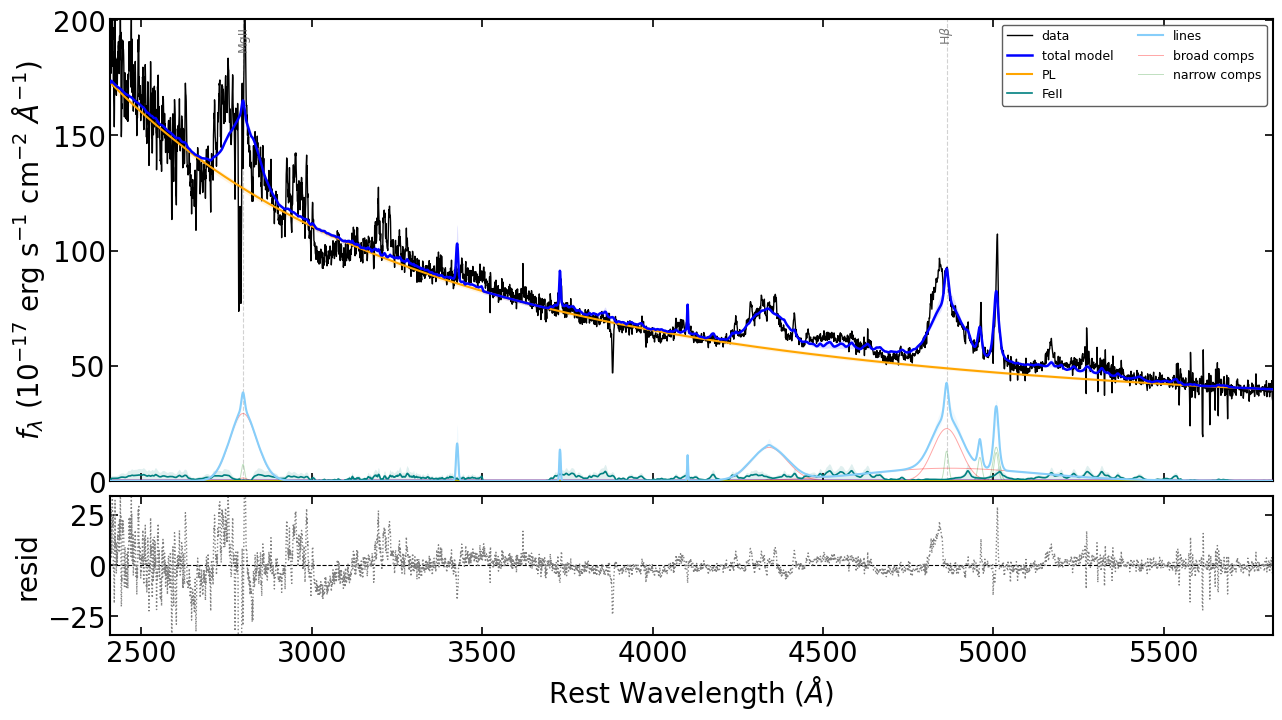

In [4]:
q = QSOFit(
    lam=lam,
    flux=flux,
    err=err,
    z=z,
    ra=ra,
    dec=dec,
    filename=sdss_filename,
    output_path=".",
)

q.fit(
    deredden=True,
    fit_method="optax+nuts",
    fit_lines=True,
    decompose_host=False,
    fit_pl=True,
    fit_fe=True,
    fit_bc=False,
    fit_poly=True,
    prior_config=prior_config,
    dsps_ssp_fn="../tempdata.h5",
    optax_steps=600,
    optax_lr=1e-2,
    nuts_warmup=50,
    nuts_samples=50,
    nuts_chains=1,
    plot_fig=True,
    save_fig=False,
    save_result=False,
)


In [5]:
q.plot_mcmc_diagnostics(
    param_names='Fe_uv_FWHM',
    do_trace=True,
    do_corner=True,
    max_vector_elems=2,
    corner_bins=25,
    corner_max_points=1500,
)
